# Exploratory Data Analysis of Titanic

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [68]:
# Better plot style
plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")

# Load Dataset

In [69]:
df=pd.read_csv(r"C:\Users\Abhishek\Documents\Coding_files\Analyst Tasks\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Basic Exploration

In [70]:
print("\n===== FIRST 5 ROWS =====")
print(df.head())


===== FIRST 5 ROWS =====
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   

In [71]:
print("\n===== DATASET INFO =====")
print(df.info())


===== DATASET INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [72]:
df['Age'].fillna(df['Age'].median(), inplace=True)

# Convert float → nullable integer correctly
df['Age'] = df['Age'].round().astype('Int64')

# Verify
print(df['Age'].dtype)

Int64


C:\Users\Abhishek\AppData\Local\Temp\ipykernel_18408\322994822.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)


In [73]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    Int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: Int64(1), float64(1), int64(5), str(5)
memory usage: 84.5 KB
None


In [74]:
print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())


===== STATISTICAL SUMMARY =====
       PassengerId    Survived      Pclass        Age       SibSp       Parch  \
count   891.000000  891.000000  891.000000      714.0  891.000000  891.000000   
mean    446.000000    0.383838    2.308642  29.693277    0.523008    0.381594   
std     257.353842    0.486592    0.836071  14.524527    1.102743    0.806057   
min       1.000000    0.000000    1.000000        0.0    0.000000    0.000000   
25%     223.500000    0.000000    2.000000       20.0    0.000000    0.000000   
50%     446.000000    0.000000    3.000000       28.0    0.000000    0.000000   
75%     668.500000    1.000000    3.000000       38.0    1.000000    0.000000   
max     891.000000    1.000000    3.000000       80.0    8.000000    6.000000   

             Fare  
count  891.000000  
mean    32.204208  
std     49.693429  
min      0.000000  
25%      7.910400  
50%     14.454200  
75%     31.000000  
max    512.329200  


# Value Counts (Categorical Analysis)

In [75]:
print("\nSurvival Count:")
print(df['Survived'].value_counts())


Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64


In [76]:
print("\nPassenger Class Count:")
print(df['Pclass'].value_counts())


Passenger Class Count:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [77]:
print("\nGender Count:")
print(df['Sex'].value_counts())


Gender Count:
Sex
male      577
female    314
Name: count, dtype: int64


In [78]:
print("\nEmbarked Count:")
print(df['Embarked'].value_counts())


Embarked Count:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


# Missing Values Check

In [79]:
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


===== MISSING VALUES =====
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Dealing with Missing Values

In [80]:
cabin_mode=df['Cabin'].mode()[0][0:3]
df['Cabin']=df['Cabin'].fillna(cabin_mode)

In [81]:
age_med=df['Age'].median()
df['Age']=df['Age'].fillna(age_med)

In [82]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_18408\3744086084.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [83]:
print("\n===== AFTER CLEANING =====")
print(df.isnull().sum())


===== AFTER CLEANING =====
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64


# Pairplot (Relationships)

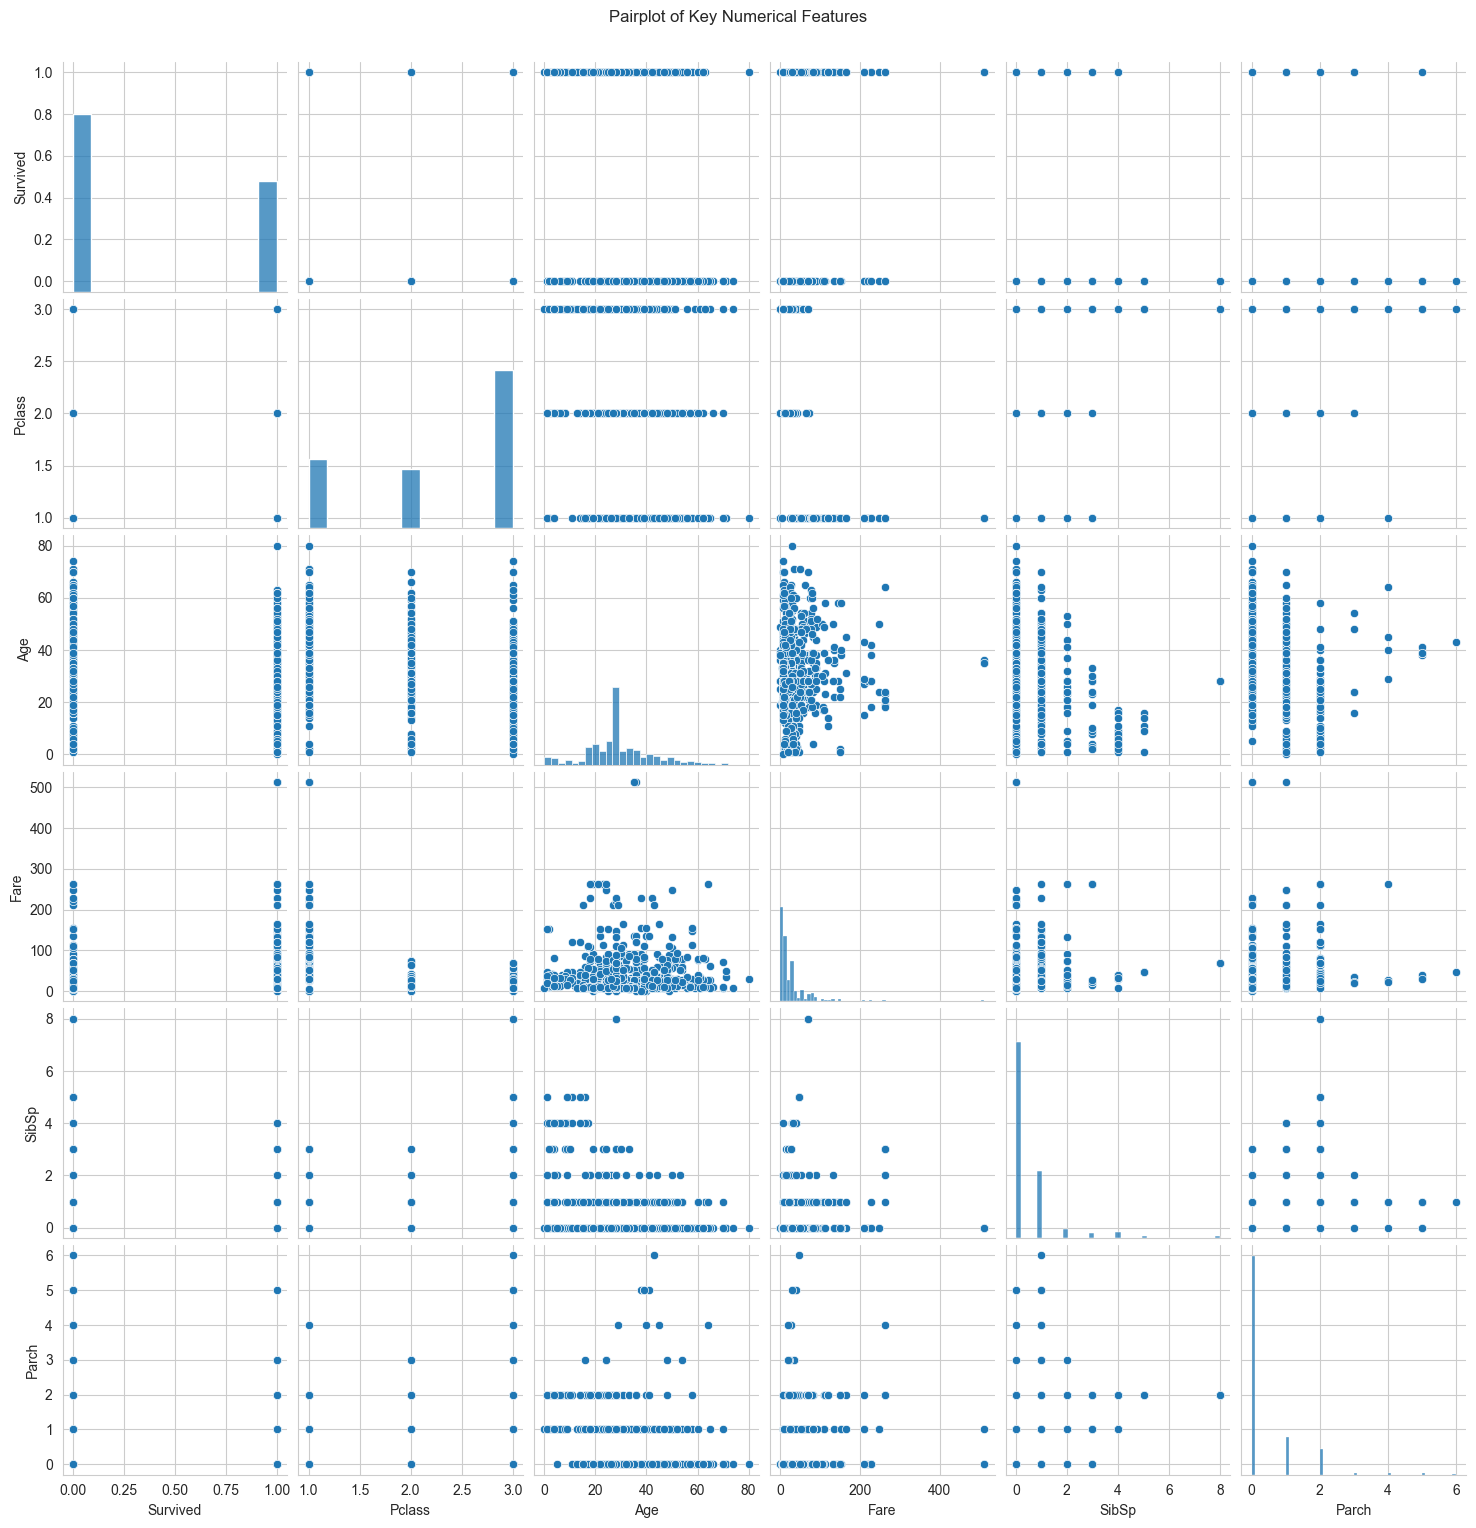

In [84]:
sns.pairplot(df[['Survived','Pclass','Age','Fare','SibSp','Parch']])
plt.suptitle("Pairplot of Key Numerical Features", y=1.02)
plt.show()

# Correlation Heatmap

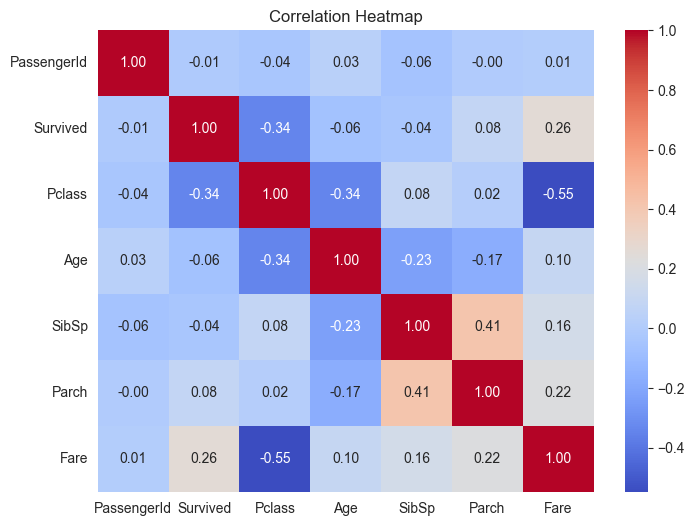

In [85]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# Histogram — Age Distribution

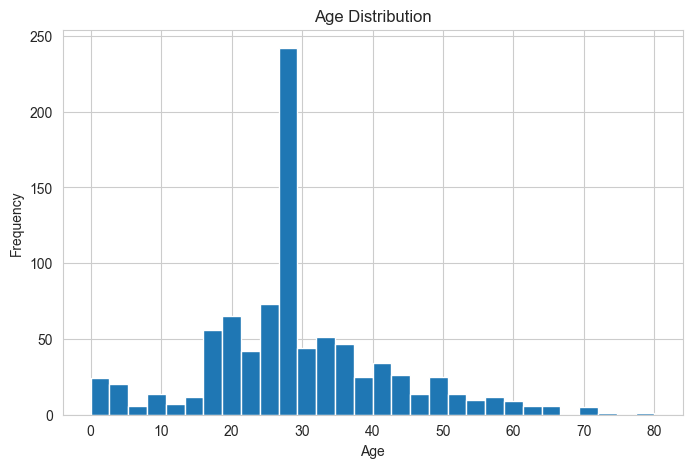

In [86]:
plt.figure()
df['Age'].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Boxplot — Fare

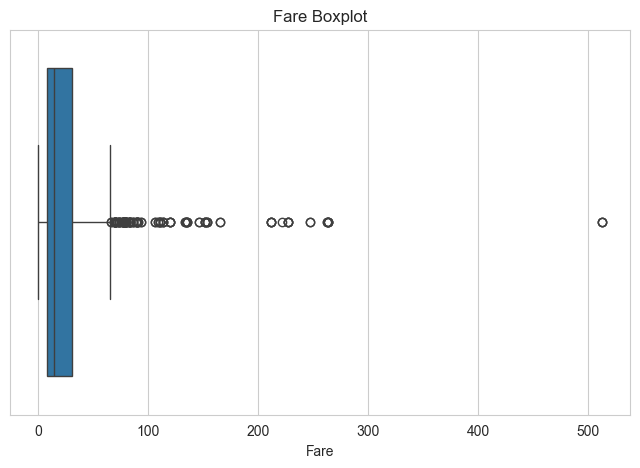

In [87]:
plt.figure()
sns.boxplot(x=df['Fare'])
plt.title("Fare Boxplot")
plt.show()

# Scatterplot — Age vs Fare

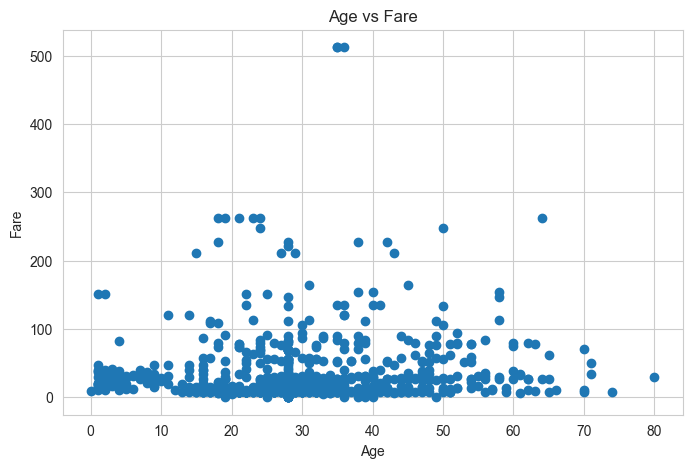

In [88]:
plt.figure()
plt.scatter(df['Age'], df['Fare'])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

# Survival by Gender

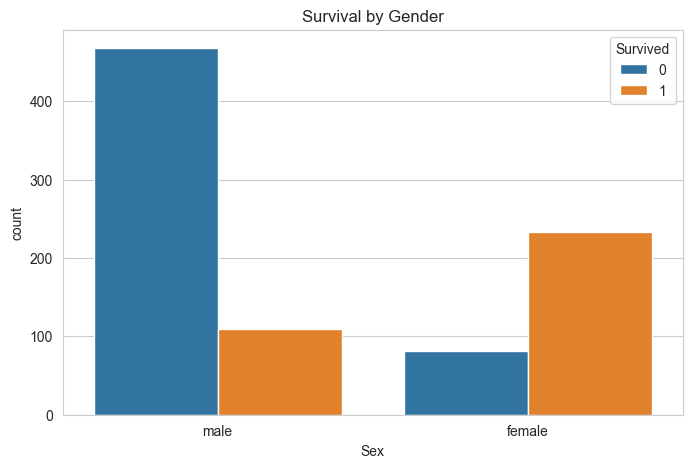

In [89]:
plt.figure()
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Observations

In [91]:
# Pairplot- Helps identify relationships between survival and numeric features

# Coorelation- Shows strongest relationships with survival

# Histogram- Most passengers are between 20–40 years

# Boxplot- Fare has many high-value outliers

# Scatterplot- No strong linear relationship

# Survival by Gender- Females survived more than males

# Survival by Passenger Class- 1st class passengers survived more

# Final Findings

In [92]:
print("\n===== FINAL FINDINGS =====")
print("""
1. Passenger class strongly impacts survival.
2. Females had higher survival rates.
3. Fare distribution is highly skewed.
4. Age contains missing values that need treatment.
5. No strong linear relationship between Age and Fare.
6. Dataset is suitable for classification modeling.
""")


===== FINAL FINDINGS =====

1. Passenger class strongly impacts survival.
2. Females had higher survival rates.
3. Fare distribution is highly skewed.
4. Age contains missing values that need treatment.
5. No strong linear relationship between Age and Fare.
6. Dataset is suitable for classification modeling.

